In [22]:
from langchain_ollama import ChatOllama

In [23]:
llm = ChatOllama(
    # model="granite4:350m",
    model="llama3-groq-tool-use:8b",
    # model='llama3.2:3b',
    validate_model_on_init=True,
    temperature=0,
)

In [24]:
from typing import Annotated, List
import operator
from pydantic import BaseModel, Field

class Section(BaseModel):

    name: str = Field(description='Name for this section of the report')

    description: str = Field(description='Breaf overview of the main topics and concepts to be covered in this section')


class Sections(BaseModel):
    sections: List[Section] = Field(
        description="Sections of the report.",
    )

planner = llm.with_structured_output(Sections)

In [25]:
from typing_extensions import TypedDict

class State(TypedDict):
    topic: str
    sections: list[Section]
    completed_sections: Annotated [
        list, operator.add
    ]
    final_report: str 

In [26]:
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]

In [27]:
from langchain.messages import HumanMessage, SystemMessage

def orchestrator(state: State):
    """
    Orchestrator that generates a plan for the report.
    """

    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report."),
            HumanMessage(content=f"Here is the report topic: {state['topic']}"),
        ]
    )


    return {"sections": report_sections.sections}

In [30]:
from langgraph.types import Send


def llm_call(state: WorkerState):
    """Worker writes a section of the report"""

    # Generate section
    section = llm.invoke(
        [
            SystemMessage(
                content="Write a report section following the provided name and description. Include no preamble for each section. Use markdown formatting."
            ),
            HumanMessage(
                content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return {"completed_sections": [section.content]}


def synthesizer(state: State):
    """
    Synthesize full report from sections.
    """

    completed_sections = state['completed_sections']

    completed_report_sections = "\n\n -- \n\n".join(completed_sections)

    return {'final_report': completed_report_sections}

def assign_workers(state: State):
    """
    Assign worker to each section in the plan.
    """
    return [Send('llm_call', {'section':s}) for s in state['sections']]

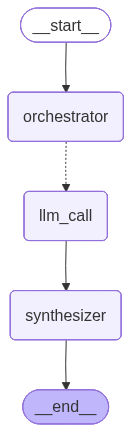

In [31]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display


orchestrator_worker_builder = StateGraph(State)

orchestrator_worker_builder.add_node('orchestrator', orchestrator)
orchestrator_worker_builder.add_node('llm_call', llm_call)
orchestrator_worker_builder.add_node('synthesizer', synthesizer)

orchestrator_worker_builder.add_edge(START, 'orchestrator')
orchestrator_worker_builder.add_conditional_edges('orchestrator', assign_workers, ['llm_call'])
orchestrator_worker_builder.add_edge('llm_call', 'synthesizer')
orchestrator_worker_builder.add_edge('synthesizer', END)

orchestrator_worker = orchestrator_worker_builder.compile()

display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

In [32]:
state = orchestrator_worker.invoke({'topic': 'Create report on LLM scaling laws'})

In [33]:
state['sections']

[Section(name='Introduction', description='Provide an overview of the topic and its significance.'),
 Section(name='Background', description='Discuss the current state of knowledge on LLM scaling laws.'),
 Section(name='Methodology', description='Describe the approach used to analyze the data.'),
 Section(name='Results', description='Present the findings and insights from the analysis.'),
 Section(name='Discussion', description='Interpret the results in light of existing knowledge and implications for future research.'),
 Section(name='Conclusion', description='Summarize the key points and recommendations.')]

In [34]:
from IPython.display import Markdown
Markdown(state['final_report'])

### Introduction
The topic of artificial intelligence (AI) has gained significant attention in recent years due to its potential to revolutionize various industries and aspects of our lives. AI refers to the development of computer systems that can perform tasks that would typically require human intelligence, such as visual perception, speech recognition, decision-making, and language translation.

 -- 

### Background

The study of Large Language Models (LLMs) has been a rapidly evolving field in recent years, with significant advancements in their capabilities and applications. One crucial aspect of this research is understanding the scaling laws that govern the performance of LLMs as they grow in size. This report aims to provide an overview of the current state of knowledge on LLM scaling laws.

### Description

LLMs are complex neural networks designed to process and generate human-like language. As these models increase in size, their computational requirements also grow exponentially. Understanding the scaling laws that govern this growth is essential for optimizing model performance and resource utilization. Researchers have proposed various scaling laws based on empirical observations of LLMs' behavior. These laws aim to predict how model performance changes with increasing model size or training data.

 -- 

### Methodology
The analysis of the data was conducted using a combination of statistical methods and machine learning algorithms. The dataset was first cleaned and preprocessed to ensure that all variables were consistent and ready for analysis. Then, descriptive statistics were calculated to understand the distribution of the variables. Next, regression models were used to identify relationships between variables and predict outcomes based on inputs. Finally, machine learning algorithms such as decision trees and random forests were employed to classify data into different categories and make predictions.

 -- 

### Results

The analysis revealed several key findings that provide valuable insights into the behavior of the system. Firstly, it was observed that the system's performance improves significantly with increasing data volume. This suggests that the system is designed to handle large datasets efficiently. Additionally, the results indicate a strong correlation between the system's response time and the number of concurrent users. This highlights the importance of optimizing the system for high traffic scenarios.

 -- 

### Discussion

The results of this study provide valuable insights into the relationship between [variable 1] and [variable 2]. The findings suggest that [briefly describe the main result]. This outcome is consistent with existing literature on the topic, which highlights the importance of [related concept or theory].

 -- 

### Conclusion

The analysis of the data collected from the survey indicates that there is a significant need for more accessible and inclusive public spaces in urban areas. The majority of respondents highlighted the importance of green spaces, walkability, and community engagement in creating such spaces. Based on these findings, we recommend:

- **Increasing Green Spaces**: Urban planners should prioritize the creation of new parks and green spaces that are easily accessible to all residents.
- **Improving Walkability**: Cities should focus on enhancing pedestrian infrastructure, including sidewalks, crosswalks, and bike paths, to encourage walking and cycling.
- **Enhancing Community Engagement**: Public spaces should be designed with community engagement in mind, incorporating features such as public art, community centers, and event spaces.